### Import zbioru danych

In [1]:
import pandas as pd

df = pd.read_csv('AmesHousing.csv')

### Rozmiar zbioru danych

In [3]:
df.shape

(2930, 82)

Nasz `unikalny` zbior danych sklada sie z `2930` obserwacji oraz `82` cech.

### Unikatowe Wartości

In [4]:
uniqueCounts = df.nunique().sort_values(ascending=True)

uniqueCounts_dataFrame = uniqueCounts.reset_index()
uniqueCounts_dataFrame.columns = ['Feature', 'Unique Values']
uniqueCounts_dataFrame
# print(uniqueCounts_dataFrame.to_string(index=False))

,Feature,Unique Values
0,Central Air,2
1,Street,2
2,Alley,2
3,Bsmt Half Bath,3
4,Paved Drive,3
...,...,...
77,Bsmt Unf SF,1137
78,Gr Liv Area,1292
79,Lot Area,1960
80,PID,2930


Powyższa tabela składa się z trzech kolumn:

1. **Index**  
   Automatycznie wygenerowany numer wiersza

2. **Feature**  
   Nazwa cechy (kolumny) w zbiorze danych.

3. **Unique Values**  
   Liczba unikatowych wartości przyjmowanych przez daną cechę w całym zbiorze obserwacji.  
---
- Jeśli **Unique Values = 2**, to zmienna jest binarna (np. 0/1 lub TAK/NIE).  
  – Przykład: `Central Air` przyjmuje wartości `Y`/`N`, stąd ma 2 unikalne wartości.

- **Cechy dyskretne** to te o niewielkiej liczbie unikatów (zwykle 3–10).  
  – Przykłady: `Fireplace` przyjmuje juz 5 wartosci

- **Cechy ciągłe** mają bardzo dużo unikatowych wartości,   
  – Przykłady: `Lot Area` przyjmuje 1960 unikalnych wartosci

Dzięki temu podziałowi łatwo zidentyfikujemy, które cechy traktujemy jako dyskretne, a które jako ciągłe i z nich wybierzemy dwa zestawy po 7 cech dla kazdego typu


### Selekcja cech dyskretnych oraz ciągłych

In [5]:
discreteFeatures = [
    'Central Air',
    'Paved Drive',
    'Bsmt Full Bath',
    'Kitchen AbvGr',
    'Fireplaces',
    'Bsmt Half Bath',
    'Garage Cars'
]

1. **`Central Air`**  
   - **Opis:** Czy budynek posiada klimatyzację (`Y`/`N`).  
   - **Typ:** Zmienna binarna (2 wartości).  
   - **Zakres wartości:** `Y` (tak), `N` (nie).  

2. **`Paved Drive`**  
   - **Opis:** Rodzaj utwardzenia podjazdu.  
   - **Typ:** Zmienna nominalna.  
   - **Zakres wartości:** `N` (brak utwardzenia), `P` (częściowe), `Y` (tak).  

3. **`Bsmt Full Bath`**  
   - **Opis:** Liczba pełnych łazienek w piwnicy.  
   - **Typ:** Zmienna licznikowa.  
   - **Zakres wartości:** 0–3.  

4. **`Kitchen AbvGr`**  
   - **Opis:** Liczba kuchni nad poziomem gruntu.  
   - **Typ:** Zmienna licznikowa.  
   - **Zakres wartości:** zwykle 1–2.  

5. **`Fireplaces`**  
   - **Opis:** Liczba kominków w domu.  
   - **Typ:** Zmienna licznikowa.  
   - **Zakres wartości:** 0–4.  

6. **`Bsmt Half Bath`**  
   - **Opis:** Liczba „połówkowych” łazienek w piwnicy.  
   - **Typ:** Zmienna licznikowa.  
   - **Zakres wartości:** 0–2.  

7. **`Garage Cars`**  
   - **Opis:** Liczba miejsc parkingowych w garażu.  
   - **Typ:** Zmienna licznikowa.  
   - **Zakres wartości:** 0–4.  

---

*Zdecydowalismy sie na wybor takich cech, poniewaz kazda z nich ma liczbe unikatowych wartosci (<10), dobrze bedzie sie je wizualizowac, uwazamy ze dobrze oddadza wplyw na atrakcyjnosc mieszkania*


In [6]:
continuousFeatures = [
    'Lot Area',
    'Gr Liv Area',
    'Total Bsmt SF',
    '1st Flr SF',
    '2nd Flr SF',
    'Garage Area',
    'SalePrice'
]

1. **`Lot Area`**  
   - **Opis:** Powierzchnia działki w stopach kwadratowych.  
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od kilku tysięcy do ponad 200 000 ft².

2. **`Gr Liv Area`**  
   - **Opis:** Powierzchnia użytkowa mieszkalna powyżej poziomu gruntu w stopach kwadratowych. 
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od kilkuset do ponad 4500 ft².

3. **`Total Bsmt SF`**  
   - **Opis:** Całkowita powierzchnia piwnicy w stopach kwadratowych.  
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od 0 (brak piwnicy) do około 6000 w stopach kwadratowych.

4. **`1st Flr SF`**  
   - **Opis:** Powierzchnia parteru w stopach kwadratowych.  
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od kilkuset do ponad 4000 ft².

5. **`2nd Flr SF`**  
   - **Opis:** Powierzchnia piętra w stopach kwadratowych. 
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od 0 (domy parterowe) do około 2000 ft².

6. **`Garage Area`**  
   - **Opis:** Powierzchnia garażu w stopach kwadratowych. 
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od 0 (brak garażu) do ponad 1400 ft².

7. **`SalePrice`**  
   - **Opis:** Cena sprzedaży domu w dolarach amerykańskich.  
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od kilkudziesięciu tysięcy do ponad miliona dolarów.


In [7]:
myData = discreteFeatures + continuousFeatures
summary = pd.DataFrame({
    'Feature': myData,
    'Type':   ['discrete']*len(discreteFeatures) + ['continuous']*len(continuousFeatures),
    'Unique Values': [df[f].nunique() for f in myData]
})
summary

,Feature,Type,Unique Values
0,Central Air,discrete,2
1,Paved Drive,discrete,3
2,Bsmt Full Bath,discrete,4
3,Kitchen AbvGr,discrete,4
4,Fireplaces,discrete,5
5,Bsmt Half Bath,discrete,3
6,Garage Cars,discrete,6
7,Lot Area,continuous,1960
8,Gr Liv Area,continuous,1292
9,Total Bsmt SF,continuous,1058


Nasz nowy zbiór, na którym będziemy pracować, składa się z:
- **14 cech**:  
  - 7 cech dyskretnych  
  - 7 cech ciągłych  
- **2930 obserwacji**  

Ograniczylismy sie do tych 14 cech, zatem duzo latwiejsze staje sie przeprowadzenie analizy dancyh jak i sama wizualizacja danych.  
Dodatkwo zachowujemy balans miedzy zmiennyli liczbowymi a kategorycznymi.


### Opis zbioru danych

Zdecydowaliśmy sie na **Ames Housing Dataset** jako nasz unikalny zbiór danych.  
Zbiór danych pochodzi z Kaggle [Ames Data Set](https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset).  

- **Liczba obserwacji:** 2 930  
- **Liczba cech:** 79  
- **Cechy:** różnorodne atrybuty opisujące domy  
- **Zmienna docelowa:** `SalePrice` (cena sprzedaży domu w USD)  

Opis zbioru danych na Kaggle:
> _“The Ames Housing Dataset is widely used in the machine learning community for tasks such as regression modeling, feature engineering, and predictive analytics related to housing prices. It serves as a valuable resource for developing and testing machine learning algorithms and techniques in the real estate domain.”_    

Podsumowujac, z tychze 79 cech wybralismy:
- ogolne 14 cech
    - 7 cech dyskretnych  
    - 7 cech ciągłych


Dzięki wybraniu 7 zmiennych dyskretnych i 7 zmiennych ciągłych, uzyskujemy zrównoważony zestaw danych idealny do dalszej analizy statystycznej.


TODO:
- wizualizacja kazdej cechy ???


### Estymacja punktowa - Dyskretne cechy

#### Plan analizy cech dyskretnych

**Cechny licznikowe**
  1. Średnia (mean)  
  2. Wariancja (variance)  
  3. Odchylenie standardowe (std)  
  4. Odchylenie przeciętne (MAD)  
  5. Mediana (median)  
  6. Moda (mode)  
  7. Skośność (skewness)  
  8. Kurtoza (kurtosis)  
  9. 1-szy i 3-ci kwartyl (quantiles 0.25, 0.75)  
  10. Rozstęp międzykwartylowy (IQR = Q3–Q1)

**Cechny nominalne**
  1. Tabelę częstości (count)  
  2. Udział (proportion)  
  3. Dominującą kategorię (mode)

In [14]:
import pandas as pd
import numpy as np
from scipy import stats

myData = pd.read_csv('AmesHousing.csv')

discreteFeatures_count = [
    'Bsmt Full Bath',
    'Kitchen AbvGr',
    'Fireplaces',
    'Bsmt Half Bath',
    'Garage Cars'
]
discreteFeatures_nominal = [
    'Central Air',
    'Paved Drive'
]

results = []
for f in discreteFeatures_count:
    x = myData[f].dropna()
    mu    = x.mean()
    var   = x.var(ddof=1)
    std   = x.std(ddof=1)
    mad   = (x - mu).abs().mean()
    med   = x.median()
    mode  = x.mode().iloc[0]
    skew  = x.skew()
    kurt  = x.kurtosis()
    q1, q3 = x.quantile([0.25, 0.75])
    iqr   = q3 - q1

    results.append({
        'Feature':       f,
        'Mean':          mu,
        'Variance':      var,
        'Std':       std,
        'MAD':           mad,
        'Median':        med,
        'Mode':          mode,
        'Skewness':      skew,
        'Kurtosis':      kurt,
        'Q1 (25%)':      q1,
        'Q3 (75%)':      q3,
        'IQR':           iqr
    })

discreteFeatures_countStats = pd.DataFrame(results).set_index('Feature')
display(discreteFeatures_countStats)

,Mean,Variance,Std,MAD,Median,Mode,Skewness,Kurtosis,Q1 (25%),Q3 (75%),IQR
Feature,,,,,,,,,,,
Bsmt Full Bath,0.431352,0.275436,0.524820,0.502950,0.0,0.0,0.616639,-0.747989,0.0,1.0,1.0
Kitchen AbvGr,1.044369,0.045829,0.214076,0.086818,1.0,1.0,4.313825,19.869743,1.0,1.0,0.0
Fireplaces,0.599317,0.419802,0.647921,0.581727,1.0,0.0,0.739215,0.101508,0.0,1.0,1.0
Bsmt Half Bath,0.061134,0.060149,0.245254,0.114960,0.0,0.0,3.940795,14.921740,0.0,0.0,0.0
Garage Cars,1.766815,0.578461,0.760566,0.596771,2.0,2.0,-0.219836,0.244969,1.0,2.0,1.0


Teraz krotko zinterpretujemy otrzymane wyniki, opiszemy krotko kazdy estymator o czym mówi.

`Średnia` - to suma wartosci podzielona przez liczbe obserwacji.  
- W naszym przypadku widzimy, w wiekszosci domom jest mnie niz pol pelnej lazienki w piwnicy, wiec wiekszosc domow jej nie ma.  
- Niemal zawsze jest jedna kuchnia (nad poziomem gruntu), czasem nawet dwie sa kuchnie.  
- Wiekszosc domow ma zazwyczaj jeden kominek albo wcale.  
- Rzadko wystepuja polowy lazienek w piwnicy
- srednio domy maja prawie 2 miesjca prawkingowe.

`Wariancja` - to miara rozrzutu wokol sredniej
- **Bsmt Full Bath:** 0.28 – umiarkowany rozrzut wokół 0.43.  
- **Kitchen AbvGr:** 0.05 – bardzo mały rozrzut, prawie każda wartość to 1.  
- **Fireplaces:** 0.42 – umiarkowany rozrzut (0 lub 1, rzadziej 2–3).  
- **Bsmt Half Bath:** 0.06 – rozrzut praktycznie zerowy (prawie wszędzie 0).  
- **Garage Cars:** 0.58 – umiarkowany rozrzut wokół ~1.8. 

`Odchylenie standardowe` - pierwiastek z wariancji, srednie odchylenie od sredniej
- **Bsmt Full Bath:** 0.52  
- **Kitchen AbvGr:** 0.21  
- **Fireplaces:** 0.65  
- **Bsmt Half Bath:** 0.25  
- **Garage Cars:** 0.76 

`Odchylenie przecietne (MAD)` - Średnia z bezwzględnych odchyleń od średniej, jest mniej wrazliwa na wartosci odstajace niz odch. std.
- **Bsmt Full Bath:** 0.50 – przeciętnie odchylenie od średniej to pół łazienki.  
- **Kitchen AbvGr:** 0.09 – większość domów ma dokładnie jedną kuchnię.  
- **Fireplaces:** 0.58  
- **Bsmt Half Bath:** 0.11  
- **Garage Cars:** 0.60 

`Mediana` - Wartość środkowa w uporządkowanym zbiorze. 
- **Bsmt Full Bath:** 0 – co najmniej połowa domów nie ma pełnej łazienki w piwnicy.  
- **Kitchen AbvGr:** 1 – przynajmniej połowa ma jedną kuchnię.  
- **Fireplaces:** 1 – przynajmniej połowa ma co najmniej 1 kominek.  
- **Bsmt Half Bath:** 0 – połowa domów nie ma połowy łazienki w piwnicy.  
- **Garage Cars:** 2 – połowa garaży pomieści co najmniej dwa auta.

`Moda` - Najczęściej występująca wartość.   
- **Bsmt Full Bath:** 0 – najwięcej domów nie ma pełnej łazienki w piwnicy.  
- **Kitchen AbvGr:** 1 – przeważnie jedna kuchnia.  
- **Fireplaces:** 0 – najczęściej brak kominka.  
- **Bsmt Half Bath:** 0 – najczęściej brak połówkowej łazienki w piwnicy.  
- **Garage Cars:** 2 – najczęściej garaż na dwa samochody.

`Kwantyle` - 
- **Q1 (25%)** – wartość poniżej której znajduje się 25% danych.  
- **Q3 (75%)** – wartość poniżej której znajduje się 75% danych.  
- **IQR = Q3 – Q1** – rozstęp środkowych 50% danych.  
  | feature            | Q1  | Q3  | IQR |
  |--------------------|-----|-----|-----|
  | Bsmt Full Bath     | 0   | 1   | 1   |
  | Kitchen AbvGr      | 1   | 1   | 0   |
  | Fireplaces         | 0   | 1   | 1   |
  | Bsmt Half Bath     | 0   | 0   | 0   |
  | Garage Cars        | 1   | 2   | 1   |

`Skośność` - mierzy asyetrie rozkladu wzgledem sredniej, >0 prawy ogon, <0 lewy ogon 
- **Bsmt Full Bath:** 0.62 – (kilka domów ma więcej niż 1 łazienkę).  
- **Kitchen AbvGr:** 0.31 – (nieliczni mają 2 kuchnie).  
- **Fireplaces:** 0.74 – umiarkowana skośność dodatnia.  
- **Bsmt Half Bath:** 3.94 – (praktycznie wszędzie 0, nieliczne 1–2).  
- **Garage Cars:** –0.22 – (kilka domów ma 0 lub 1 miejsce, większość 2).

`Kurtoza` - >0 mowi ze dane ukaldaja sie w ostre szczyty, <0 rozkald jest splaszczony 
- **Bsmt Full Bath:** –0.75 – lekko spłaszczony rozkład.  
- **Kitchen AbvGr:** 19.87 – ekstremalnie wysokie skupienie na 1 i rzadkie „wpadki” na 2 (ciężkie ogony).  
- **Fireplaces:** 0.10 – nieznacznie cięższe ogony.  
- **Bsmt Half Bath:** 14.92 – bardzo ciężkie ogony (zbiór prawie wyłącznie z zerami).  
- **Garage Cars:** 0.24 – lekkie wydłużenie ogonów.
 


In [15]:
import pandas as pd

for feat in discreteFeatures_nominal:
    counts = myData[feat].value_counts(dropna=False)
    props  = myData[feat].value_counts(normalize=True, dropna=False)
    freq_df = pd.DataFrame({
        'category':   counts.index,
        'count':      counts.values,
        'proportion': props.values
    })
    display(freq_df)



,category,count,proportion
0,Y,2734,0.933106
1,N,196,0.066894


,category,count,proportion
0,Y,2652,0.905119
1,N,216,0.073720
2,P,62,0.021160


`Central Air`
- **Y (tak):** 2 734 obserwacje (~93%)  
- **N (nie):** 196 obserwacji (~7%)   
> Większość domów w Ames wyposażona jest w centralną klimatyzację.

`Paved Drive ` 
- **Y (tak):** 2 652 obserwacje (91%)  
- **N (brak):** 216 obserwacji (7%)  
- **P (częściowo):**  62 obserwacje (2%)  
> Ponad 90% posesji ma w pełni utwardzony podjazd, a jedynie niewielki odsetek jest utwardzony częściowo.  


### Estymacja przedzialowa - Dyskretne cechy

#### Plan analizy cech dyskretnych

Przechodzac do sekcji `estymacji przedzialowej`, zajmiemy sie wyznaczeniem **95% przedziałów ufności** dla naszych wybranych cech dyskretnych.  

Omówmy sobie pokrótce zastosowane metody:
- `Parametryczne przedziały ufności dla średniej`  
w tej metodzei zaklada sie ze rozklad jest w przyblizeniu normalny (w naszym przypadku t-Studenta),  
Dowiemy sie w jakim przedziale znajduje sie srednia dla danej cechy

- `Parametryczne przedziały ufności dla wariancji`  
uzywamy tutaj rozkladu chi-kwadrat
- `Nieparametryczne przedziały ufności metodą bootstrap`  
losujemy 2000 probek z naszego zbioru, obliczamy srednia kazdej z nich,  
wyznaczamy granice przedzialu (przy pomocy percentyli tych srednich)
    > Metoda przydatna gdy rozklad jest asymetryczny

In [27]:
import pandas as pd
import numpy as np
from scipy import stats

param_mean = []
param_var  = []
boot_mean  = []

B = 2000

for feat in discreteFeatures_count:
    x = df[feat].dropna()
    n = len(x)
    mu = x.mean()
    s2 = x.var(ddof=1)
    s  = np.sqrt(s2)

    # t-Student
    se = s / np.sqrt(n)
    ci_mean_low, ci_mean_high = stats.t.interval(0.95, df=n-1, loc=mu, scale=se)
    param_mean.append({
        'feature': feat,
        'mean': mu,
        'meanLower': ci_mean_low,
        'meanHigher': ci_mean_high
    })

    # chi-kwadrat
    chi2_low  = stats.chi2.ppf(0.975, df=n-1)
    chi2_high = stats.chi2.ppf(0.025, df=n-1)
    ci_var_low  = (n-1)*s2 / chi2_low
    ci_var_high = (n-1)*s2 / chi2_high
    param_var.append({
        'feature': feat,
        'variance': s2,
        'varianceLower': ci_var_low,
        'varianceHigher': ci_var_high
    })

    # bootstrap
    boot_means = np.array([
        x.sample(n, replace=True).mean()
        for _ in range(B)
    ])
    ci_boot_low, ci_boot_high = np.percentile(boot_means, [2.5, 97.5])
    boot_mean.append({
        'feature': feat,
        'bootstrapLower': ci_boot_low,
        'bootstrapHigher': ci_boot_high
    })


In [29]:

param_mean_df = pd.DataFrame(param_mean).set_index('feature')
param_var_df  = pd.DataFrame(param_var).set_index('feature')
boot_mean_df  = pd.DataFrame(boot_mean).set_index('feature')

from IPython.display import display
print("Parametrycznie dla średniej:")
display(param_mean_df)

print("Parametrycznie dla wariancji:")
display(param_var_df)

print("Bootstrap dla średniej:")
display(boot_mean_df)

Parametrycznie dla średniej:


,mean,meanLower,meanHigher
feature,,,
Bsmt Full Bath,0.431352,0.412335,0.450370
Kitchen AbvGr,1.044369,1.036614,1.052123
Fireplaces,0.599317,0.575847,0.622788
Bsmt Half Bath,0.061134,0.052247,0.070021
Garage Cars,1.766815,1.739259,1.794370


Parametrycznie dla wariancji:


,variance,varianceLower,varianceHigher
feature,,,
Bsmt Full Bath,0.275436,0.261852,0.290111
Kitchen AbvGr,0.045829,0.043569,0.048269
Fireplaces,0.419802,0.399104,0.442160
Bsmt Half Bath,0.060149,0.057183,0.063354
Garage Cars,0.578461,0.549937,0.609275


Bootstrap dla średniej:


,bootstrapLower,bootstrapHigher
feature,,
Bsmt Full Bath,0.412568,0.449454
Kitchen AbvGr,1.037201,1.051877
Fireplaces,0.576451,0.623549
Bsmt Half Bath,0.052254,0.070697
Garage Cars,1.738819,1.794136


#### Wnioski


**`Średnia liczba pełnych łazienek w piwnicy (Bsmt Full Bath)`**  
  – 95% CI dla średniej: [0.412, 0.450]  
  > Przeciętnie mniej niż 0.5 łazienki w piwnicy (większość domów ich nie ma).

**`Średnia liczba kuchni nad poziomem gruntu (Kitchen AbvGr)`**  
  – 95% CI: [1.037, 1.052]  
  > Prawie zawsze 1 kuchnia, sporadycznie występuje druga.

**`Średnia liczba kominków (Fireplaces)`**  
  – 95% CI: [0.576, 0.623]  
  > Ponad połowa domów nie ma kominka, reszta ma zwykle 1, rzadziej 2–3.

**`Średnia liczba „połówkowych” łazienek w piwnicy (Bsmt Half Bath)`**  
  – 95% CI: [0.052, 0.070]  
  > Bardzo rzadkie – zaledwie kilka domów.

**`Średnia liczba miejsc w garażu (Garage Cars)`**  
  – 95% CI: [1.739, 1.794]  
  > Typowy garaż mieści około 2 aut.


### Rozklad Normalny  - Dyskretne cechy

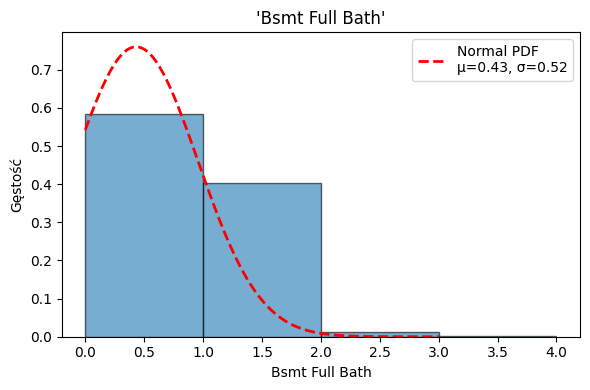

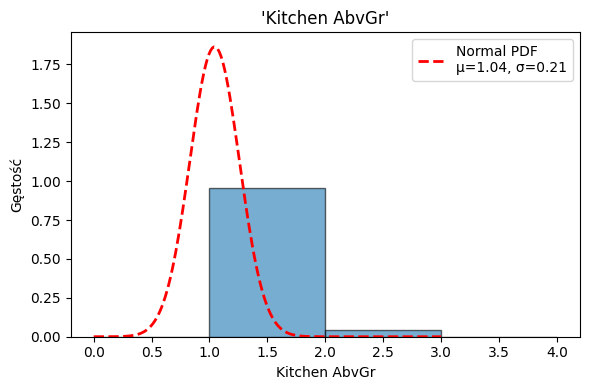

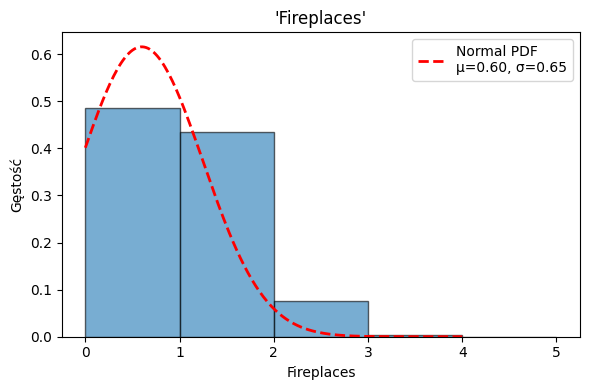

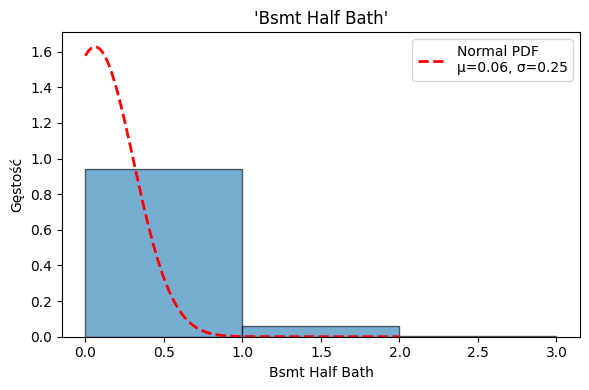

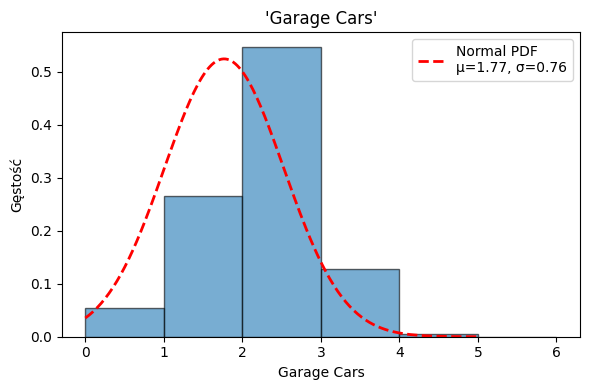

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

for feat in discreteFeatures_count:
    x = df[feat].dropna()
    mu, sigma = x.mean(), x.std(ddof=1)

    plt.figure(figsize=(6,4))

    plt.hist(x,
             bins=range(int(x.min()), int(x.max())+2),
             density=True, alpha=0.6, edgecolor='black')

    xs = np.linspace(x.min(), x.max(), 200)
    plt.plot(xs, stats.norm.pdf(xs, loc=mu, scale=sigma),
             'r--', lw=2, label=f'Normal PDF\nμ={mu:.2f}, σ={sigma:.2f}')

    plt.title(f"'{feat}'")
    plt.xlabel(feat); plt.ylabel('Gęstość')
    plt.legend(); plt.tight_layout()
    plt.show()


#### Wnioski

`BSMT FULL BATH`  
- zmienna o waskim rozkladzie, raptem zakres od [0-3]
- wyrazne odchylenie od normalnosci
- Skupienie wokol 0 i 1
> Ta cecha nie ma rozkaldu normalnego, co potwierdza uzycie testow nieparametrycznych.

`KITCHEN ABVGR`
- silne skupienie wokol wartosci 1
- byc moze dane 2 i 3 to outlinery
> zdecydowanie odchylenie od rozkladu normalnego, jednopunktowy rozklad

`FIREPLACES`
- histogram ma dwa wysokie slupki w punktach 0 i 1
- obserwujemy dodatnia skosnosc
> rozklad jest bardziej zblizony od poprzednich cech do normalnego aczkolwiek nim nie jest

`BSMT HALF BATH` 
- wiekszosc obserwacji w punkcie 0
- wyrazne odstepstwo od rozkladu normalnego
> rozkald jest wyraznie skosny i dyskretny - nie normalny

`GARAGE CARS`
- dosyc dobre wpasowanie sie w rokzlad normalny
- skupienie na wartosci 2, ok. 1/4 obserwacji skupiona na wartosci 1 i ok. 15% skupiona na wartosci 3
> rozkald tej cechy jest najbardizej symetryczny sposrod naszych cech


### Test statystyczny - Dyskretne cechy


W tej części sprawdzimy, czy nasze zmienne licznikowe istotnie różnią się od oczekiwanych wartości.

**`Test średniej (one-sample t-test)`**  
   - Porównujemy średnią próby z wartością odniesienia.  
   - H₀ to μ = μ₀ (średnia równa wartości odniesienia).  
   - Jeśli p-value < 0.05, to znaczy, że średnia jest naprawdę inna niż ta typowa wartość.

**`Test wariancji (chi-kwadrat)`**  
   Sprawdzamy, czy rozrzut danych (wariancja) pasuje do modelu Poissona (gdzie rozrzut = średnia).  
   - Jeśli p-value < 0.05, to wariancja jest znacząco inna od tej „poissonowskiej”.

Po obliczeniu tych testów otrzymamy statystyki i p-value, które wskażą nam, czy dla każdej cechy można przyjąć założenia o danej średniej i wariancji.

In [26]:
import pandas as pd
import numpy as np
from scipy import stats


results = []
for feat in discreteFeatures_count:
    x = df[feat].dropna()
    n = len(x)
    mu = x.mean()
    mode = x.mode().iloc[0]
    s2 = x.var(ddof=1)
    
    t_stat, p_mean = stats.ttest_1samp(x, popmean=mode)
    
    D = (n-1)*s2/mu
    p_lower = stats.chi2.cdf(D, df=n-1)
    p_upper = 1 - p_lower
    p_var = 2 * min(p_lower, p_upper)
    
    results.append({
        'feature': feat,
        'Dominant': mode,
        'Stat. t': t_stat,
        'mean p': p_mean,
        'χ²': D,
        'variance p': p_var
    })

test_df = pd.DataFrame(results).set_index('feature')
display(test_df)

,Dominant,Stat. t,mean p,χ²,variance p
feature,,,,,
Bsmt Full Bath,0.0,44.474112,0.000000e+00,1869.009501,2.473041e-57
Kitchen AbvGr,1.0,11.218662,1.255442e-28,128.529412,0.000000e+00
Fireplaces,0.0,50.068975,0.000000e+00,2051.665148,8.329305e-38
Bsmt Half Bath,0.0,13.488143,2.859097e-40,2879.860335,5.413807e-01
Garage Cars,2.0,-16.592961,3.629458e-59,958.637295,1.639568e-284


#### Wnioski


`Test średniej`
- **Wszystkie zmienne** mają p-value ≪ 0.05, co oznacza istotną różnicę między średnią a dominującą kategorią.
  - Np. dla **Kitchen AbvGr** średnia ≈ 1.04 różni się istotnie od 1.

`Test rozproszenia`
- **Bsmt Half Bath**  
  – p ≈ 0.54 > 0.05, czyli nie odrzucamy H₀: wariancja ~ średnia więc rozproszenie zgodne z Poissonem.  
- **Pozostałe zmienne**  
  – p ≪ 0.05, zatem odrzucamy H₀: wariancja != średnia -> rozproszenie jest inne niż w modelu Poissona.


**Kluczowe obserwacje:**
1. Średnie liczby pełnych i połówkowych łazienek, kuchni, kominków oraz miejsc w garażu istotnie różnią się od najczęstszej wartości (mode).  
2. Tylko `Bsmt Half Bath` może sugerować rozkład Poissona.  

> Nasze dane dyskretne nie spełniają standardowych założeń ani co do średniej, ani co do rozproszenia, poza wyjątkiem jednej zmiennej.

### Estymator jądrowy gęstości (KDE) - Dyskretne cechy

W tej sekcji zrobimy coś w rodzaju „wygładzania” naszych wyników z histogramu.  

**`Histogram`** rozkaldu danej cechy  
**`KDE`** (kernel density estimate) to "gladka linia" ktor aopowiada nam jak rozkaldaja sie dane po calej osi


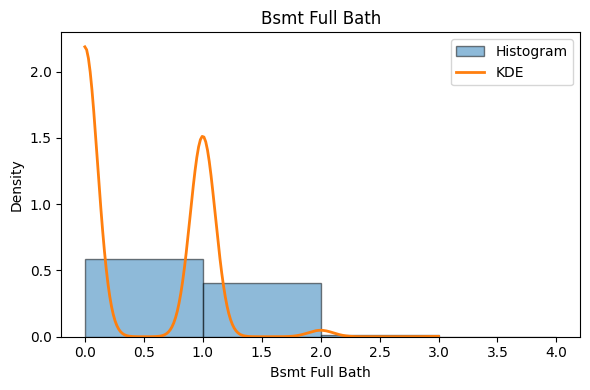

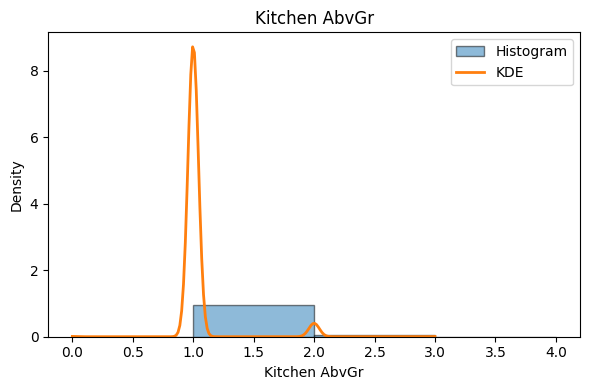

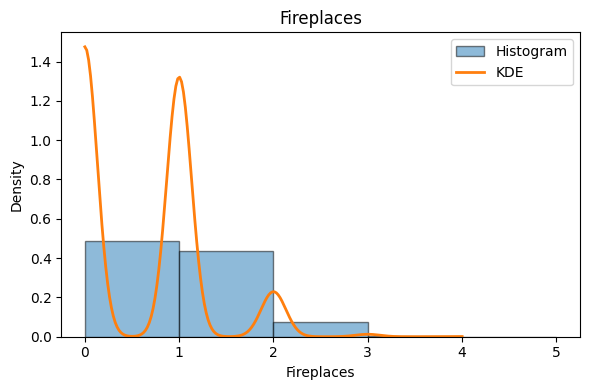

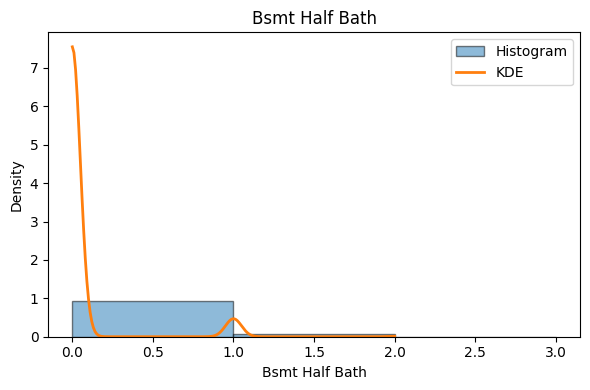

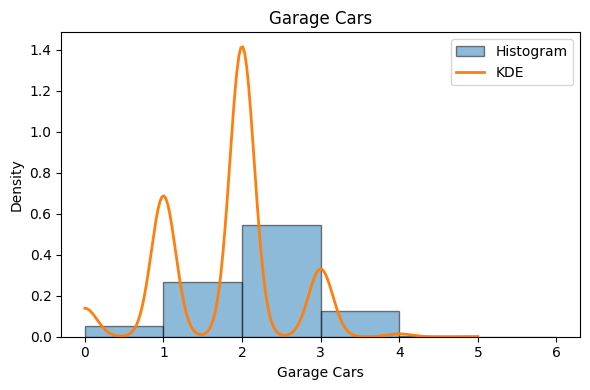

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

for feat in discreteFeatures_count:
    x = df[feat].dropna().values
    plt.figure(figsize=(6,4))
    plt.hist(x,
             bins=range(int(x.min()), int(x.max())+2),
             density=True,
             alpha=0.5,
             edgecolor='black',
             label='Histogram')

    kde = gaussian_kde(x, bw_method='scott')
    xs = np.linspace(x.min(), x.max(), 200)
    plt.plot(xs, kde(xs), lw=2, label='KDE')

    plt.title(f"{feat}")
    plt.xlabel(feat)
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()


#### Wnioski

`Bsmt Full Bath`
- dwie wyrazne gorki
    - szczyt przy 0 - ok. 60% domow nie ma lazienki w piwnicy
    - drugi mniejszy przy 1 ok. 40% domow ma dokaldnie jedna pelna lazienke
- malutki szczyt przy 2  
praktycznie brak domow z 2 i wiecej lazienek w piwnicy
> wiekszosc domow ma 0 lub 1 pelna lazienke w piwnicy

`Kitchen AbvGr`
- wyrazny szczyt przy 1
wieksozsz domow ok. 95% ma dokaldnie jedna kuchnie nad poziomem gruntu
- maly szczyt przy 2
sa domy ktore maja dwie takie kuchnie ale jest to rzadkosc
> rozkald skoncentrowany w okolicy wartosci 1, co mowi ze domy maja 1 kuchnie nad poziomem gruntu

`Fireplaces`
- dwa wyrazne szczyty
    - Pierwszy przy 0 ok. 50% domów bez kominka
    - Drugi przy 1 (ok. 40% domów z jednym kominkiem)
- maly szczyt przy 2
kilka domow ma wiecej niz 2 kominki
> domy maja 1 ewentualnie 2 kominki rzadiej wiecej

`Bsmt Half Bath`
- zmienna wyraznie dyskretna
- niewielka gorka przy 1
- lewa asymetria rozkladu
> cecha jest skosnie lewa, wiekszosc obserwacji to 0

`Garage Cars`
- najciekawszy ze wszystkich wykresow
- glowny szczyt przy 2
najczesciej agaraze mieszza 2 auta
- gorka przy 1
garaze troche rzdadziej mieszcza1 samohod
- gorka przy 3
jeszcze rzadziej miezcza 3 samochody
> generalnie domy mieszcza 2 samochody, 1 samochod i 3 samochody, symerryczna cecha
